*  Course Name: DSC 540
*  Assignment Name: Weeks 5 &6 Coding Assignment
*  Student Name: Anish Samuel

## Activity 5.01: Reading Tabular Data from a Web Page and Creating DataFrames

In [212]:
# Import packages
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [213]:
# Read page using bs4
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
response = requests.get(url)
soup = BeautifulSoup(response.content, "html.parser")
print(soup)

<!DOCTYPE html>

<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>List of countries by GDP (nominal) - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-conte

In [214]:
# Locate the correct table with name wikitable
tables = soup.find_all("table", class_="wikitable")
gdp_table = tables[0]

In [215]:
# Extract header rows
sources = gdp_table.find_all("tr")[:2]
# Get main header (IMW, WORLD BANK, United Nations)
sources_list = [th.get_text() for th in sources[0].find_all("th")]
print(sources_list)

['Country/Territory\n', 'IMF[1][12]\n', 'World Bank[13]\n', 'United Nations[14]\n']


In [216]:
# Get main header (IMW, WORLD BANK, United Nations)
sources_list = [th.get_text() for th in sources[0].find_all("th")]
print(sources_list)

['Country/Territory\n', 'IMF[1][12]\n', 'World Bank[13]\n', 'United Nations[14]\n']


In [217]:
source_names = [re.sub(r'\[\d+\]', '', header).strip() for header in sources_list]
print(source_names)

['Country/Territory', 'IMF', 'World Bank', 'United Nations']


In [218]:
# Get Sub headers
sub_headers = [th.get_text(strip=True) for th in source_names[1].find_all("th")]
print(sub_headers)

AttributeError: 'str' object has no attribute 'find_all'

In [ ]:
# Reconstruct column names by merging main and sub header
columns = ['Country/Territory']
for i in range(0, len(sub_headers), 2):
    source = source_names[1 + i//2]  # Skip first "Country/Territory" header
    columns.append(f"{source} {sub_headers[i]}")
    columns.append(f"{source} {sub_headers[i+1]}")

print(columns)

['Country/Territory', 'IMF Forecast', 'IMF Year', 'World Bank Estimate', 'World Bank Year', 'United Nations Estimate', 'United Nations Year']


In [ ]:
# Extract data (Skip first 2 header rows)
data_rows = gdp_table.find_all("tr")[2:] 
print(data_rows)

[<tr class="static-row-header" style="font-weight:bold;">
<td style="text-align:left"><span class="flagicon" style="padding-left:25px;"> </span>World</td>
<td>115,494,312 </td>
<td>2025</td>
<td>105,435,540</td>
<td>2023</td>
<td>100,834,796</td>
<td>2022
</td></tr>, <tr>
<td style="text-align:left"><span class="flagicon" style="display:inline-block;width:25px;text-align:left"><span class="mw-image-border" typeof="mw:File"><span><img alt="" class="mw-file-element" data-file-height="650" data-file-width="1235" decoding="async" height="12" src="//upload.wikimedia.org/wikipedia/en/thumb/a/a4/Flag_of_the_United_States.svg/40px-Flag_of_the_United_States.svg.png" srcset="//upload.wikimedia.org/wikipedia/en/thumb/a/a4/Flag_of_the_United_States.svg/60px-Flag_of_the_United_States.svg.png 2x" width="23"/></span></span></span> <a class="mw-redirect" href="/wiki/GDP_of_the_United_States" title="GDP of the United States">United States</a></td>
<td>30,338,000</td>
<td>2025</td>
<td>27,360,935</td>
<

In [ ]:
# Extract data to array
gdp_data = []
for row in data_rows:
    cols = row.find_all("td")
    if not cols:
        continue
    country = cols[0].get_text(strip=True)
    values = [td.get_text(strip=True).replace(',', '').split('[')[0] for td in cols[1:]]
    gdp_data.append([country] + values)
print(gdp_data)

[['World', '115494312', '2025', '105435540', '2023', '100834796', '2022'], ['United States', '30338000', '2025', '27360935', '2023', '25744100', '2022'], ['China', '19535000', '', '17794782', '', '17963170', ''], ['Germany', '4922000', '2025', '4456081', '2023', '4076923', '2022'], ['Japan', '4390000', '2025', '4212945', '2023', '4232173', '2022'], ['India', '4270000', '2025', '3549919', '2023', '3465541', '2022'], ['United Kingdom', '3731000', '2025', '3340032', '2023', '3089072', '2022'], ['France', '3284000', '2025', '3030904', '2023', '2775316', '2022'], ['Italy', '2460000', '2025', '2254851', '2023', '2046952', '2022'], ['Canada', '2331000', '2025', '2140086', '2023', '2137939', '2022'], ['Brazil', '2308000', '2025', '2173666', '2023', '1920095', '2022'], ['Russia', '2197000', '2025', '2021421', '2023', '2240422', '2022'], ['South Korea', '1948000', '2025', '1712793', '2023', '1673916', '2022'], ['Australia', '1882000', '2025', '1723827', '2023', '1776577', '2022'], ['Spain', '182

In [ ]:
# Create dataframe
gdp_df = pd.DataFrame(gdp_data, columns=columns)
gdp_df

,Country/Territory,IMF Forecast,IMF Year,World Bank Estimate,World Bank Year,United Nations Estimate,United Nations Year
0,World,115494312,2025,105435540,2023,100834796,2022
1,United States,30338000,2025,27360935,2023,25744100,2022
2,China,19535000,,17794782,,17963170,
3,Germany,4922000,2025,4456081,2023,4076923,2022
4,Japan,4390000,2025,4212945,2023,4232173,2022
...,...,...,...,...,...,...,...
205,Kiribati,311,2024,279,2023,223,2022
206,Palau,308,2024,263,2023,225,2022
207,Marshall Islands,305,2024,284,2023,279,2022
208,Nauru,161,2024,154,2023,147,2022


In [ ]:
gdp_df.head()

,Country/Territory,IMF Forecast,IMF Year,World Bank Estimate,World Bank Year,United Nations Estimate,United Nations Year
0,World,115494312,2025,105435540,2023,100834796,2022
1,United States,30338000,2025,27360935,2023,25744100,2022
2,China,19535000,,17794782,,17963170,
3,Germany,4922000,2025,4456081,2023,4076923,2022
4,Japan,4390000,2025,4212945,2023,4232173,2022


## Activity 6.01 - Handling Outliers and Missing Data

In [ ]:
# Load the data
df = pd.read_csv("data/visit_data.csv")

# Show basic info
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1000 non-null   int64  
 1   first_name  704 non-null    object 
 2   last_name   704 non-null    object 
 3   email       1000 non-null   object 
 4   gender      495 non-null    object 
 5   ip_address  1000 non-null   object 
 6   visit       974 non-null    float64
dtypes: float64(1), int64(1), object(5)
memory usage: 54.8+ KB


,id,first_name,last_name,email,gender,ip_address,visit
0,1,Sonny,Dahl,sdahl0@mysql.com,Male,135.36.96.183,1225.0
1,2,NaN,NaN,dhoovart1@hud.gov,NaN,237.165.194.143,919.0
2,3,Gar,Armal,garmal2@technorati.com,NaN,166.43.137.224,271.0
3,4,Chiarra,Nulty,cnulty3@newyorker.com,NaN,139.98.137.108,1002.0
4,5,NaN,NaN,sleaver4@elegantthemes.com,NaN,46.117.117.27,2434.0


In [ ]:
original_size = df.shape
print(f"\nOriginal data size: {original_size}")


Original data size: (1000, 7)


In [ ]:
# Find Duplicates
duplicates = df.duplicated()
print(f"Total Duplicates: {duplicates.sum()}")


Total Duplicates: 0


In [ ]:
print("\nMissing Values by Column:")
print(df.isna().sum())


Missing Values by Column:
id              0
first_name    296
last_name     296
email           0
gender        505
ip_address      0
visit          26
dtype: int64


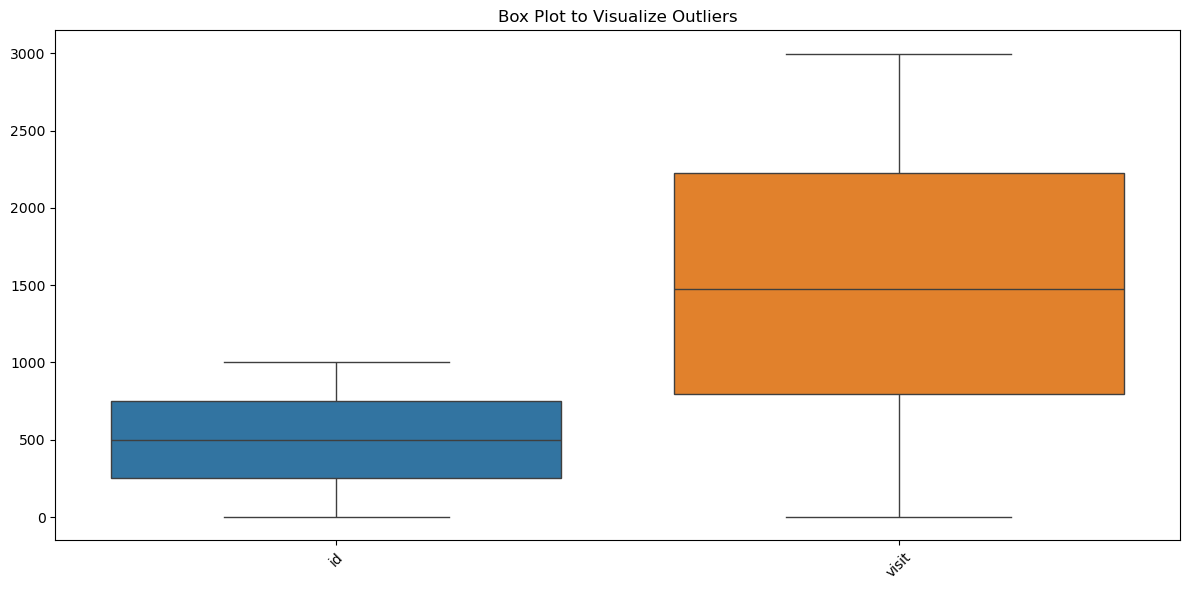

In [ ]:
# Create a box plot to check for outliers.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=['float64', 'int64']))
plt.xticks(rotation=45)
plt.title("Box Plot to Visualize Outliers")
plt.tight_layout()
plt.show()

In [ ]:
# Remove Outliers - using IQR
def remove_outliers_iqr(data, columns):
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data

# Select numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_cleaned = remove_outliers_iqr(df, numeric_cols)

In [ ]:
# Get size of cleaned data
cleaned_size = df_cleaned.shape[0]
print(f"\nCleaned data size: {cleaned_size}")


Cleaned data size: 974


In [ ]:

df1 = df[(df['visit'] <= 2900) & (df['visit'] >= 100)] 
print("New size of the data is - {}".format(*df1.shape))

New size of the data is - 923


## Exercise 3

In [ ]:
# create a table 
import sqlite3

# Connect to SQLite (it creates a file called contacts.db)
conn = sqlite3.connect("contacts.db")
cursor = conn.cursor()

# Drop the table if it already exists (for rerun convenience)
cursor.execute("DROP TABLE IF EXISTS contacts")

# Create a new table
cursor.execute("""
CREATE TABLE contacts (
    Name TEXT,
    Address TEXT,
    City TEXT,
    State TEXT,
    Zip TEXT,
    PhoneNumber TEXT
)
""")

data = [
    ("John Doe", "123 Maple St", "Springfield", "IL", "62701", "217-555-1234"),
    ("Mr Smith", "456 Maple St", "Columbus", "OH", "43004", "614-555-5678"),
    ("Mr X", "789 Maple St", "Austin", "TX", "73301", "512-555-9012"),
    ("Mr Y", "101 Elm St", "Seattle", "WA", "98101", "206-555-3456"),
    ("Test User", "202 Elm St", "Denver", "CO", "80014", "303-555-7890"),
    ("Test User 1", "303 Elm St", "Atlanta", "GA", "30301", "404-555-2345"),
    ("Mr ABC", "404 Elm St", "Phoenix", "AZ", "85001", "602-555-6789"),
    ("Tom", "505 Elm St", "Boston", "MA", "02108", "617-555-1230"),
    ("Bob", "606 Elm St", "Portland", "OR", "97201", "503-555-4567"),
    ("Anish", "707 Elm St", "Chicago", "IL", "60601", "312-555-8901")
]

cursor.executemany("INSERT INTO contacts VALUES (?, ?, ?, ?, ?, ?)", data)
conn.commit()

df = pd.read_sql("SELECT * FROM contacts", conn)
df

,Name,Address,City,State,Zip,PhoneNumber
0,John Doe,123 Maple St,Springfield,IL,62701,217-555-1234
1,Mr Smith,456 Maple St,Columbus,OH,43004,614-555-5678
2,Mr X,789 Maple St,Austin,TX,73301,512-555-9012
3,Mr Y,101 Elm St,Seattle,WA,98101,206-555-3456
4,Test User,202 Elm St,Denver,CO,80014,303-555-7890
5,Test User 1,303 Elm St,Atlanta,GA,30301,404-555-2345
6,Mr ABC,404 Elm St,Phoenix,AZ,85001,602-555-6789
7,Tom,505 Elm St,Boston,MA,02108,617-555-1230
8,Bob,606 Elm St,Portland,OR,97201,503-555-4567
9,Anish,707 Elm St,Chicago,IL,60601,312-555-8901
